In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import PercentFormatter
from collections import defaultdict, Counter
from scipy.optimize import linprog
from scipy.spatial import ConvexHull

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'serif'],
    'mathtext.fontset': 'cm',
    
    'font.size': 18,             # Base font size (up from 14)
    'axes.labelsize': 20,        # X and Y axis labels (up from 16)
    'axes.titlesize': 18,        # Individual Subplot titles (up from 14)
    'figure.titlesize': 22,      # Main Figure title/suptitle (up from 18)
    'legend.fontsize': 14,       # Legend text (up from 11)
    'xtick.labelsize': 16,       # X-axis numbers (up from 13)
    'ytick.labelsize': 16,       # Y-axis numbers (up from 13)
    
    'pdf.fonttype': 42,          # Ensures text is editable in PDF
    'ps.fonttype': 42
})
GAMMA=0.9999

# Environment Definition


In [30]:
class SlipperyYMazeMDP:
    def __init__(self, stem_length=10, branch_length=10, gamma=GAMMA, alpha=1.0):
        self.gamma = gamma
        self.stem_length = stem_length
        self.branch_length = branch_length
        self.alpha = alpha  # Probability of a random spawn
        self.n_actions = 4  # 0: Up, 1: Down, 2: Left, 3: Right
        self.n_objectives = 2 # [Gold, Gem]
        
        self.states = []
        for y in range(stem_length):
            self.states.append((0, y))
        for x in range(1, branch_length + 1):
            self.states.append((x, stem_length - 1))  # Right (Gold)
            self.states.append((-x, stem_length - 1)) # Left (Gem)
            
        self.TERMINAL_STATE = ("TERM", "TERM")
        self.state_to_idx = {s: i for i, s in enumerate(self.states)}
        self.state_to_idx[self.TERMINAL_STATE] = len(self.states)
        self.states.append(self.TERMINAL_STATE)
        
        self.terminal_idx = self.state_to_idx[self.TERMINAL_STATE]
        self.n_states = len(self.states)
        
        self.P_tensor = np.zeros((self.n_states, self.n_actions, self.n_states), dtype=np.float32)
        self.R_tensor = np.zeros((self.n_states, self.n_actions, self.n_states, self.n_objectives), dtype=np.float32)
        self._build_mdp()

    def _build_mdp(self):
        p_death_stem = 0.10  # 10% ambient death in the stem

        for s_idx, state in enumerate(self.states):
            if state == self.TERMINAL_STATE:
                self.P_tensor[s_idx, :, s_idx] = 1.0
                continue
                
            x, y = state
            is_stem = (x == 0)
            
            for a in range(self.n_actions):
                dx, dy = 0, 0
                if a == 0: dy = 1
                elif a == 1: dy = -1
                elif a == 2: dx = -1
                elif a == 3: dx = 1
                
                nx, ny = x + dx, y + dy
                p_death = p_death_stem if is_stem else 0.0
                p_alive = 1.0 - p_death
                
                if p_death > 0:
                    self.P_tensor[s_idx, a, self.terminal_idx] += p_death

                if nx == self.branch_length and ny == self.stem_length - 1: # Gold
                    self.P_tensor[s_idx, a, self.terminal_idx] += p_alive
                    self.R_tensor[s_idx, a, self.terminal_idx, :] = np.array([1.0, 0.0])
                    continue
                elif nx == -self.branch_length and ny == self.stem_length - 1: # Gem
                    self.P_tensor[s_idx, a, self.terminal_idx] += p_alive
                    self.R_tensor[s_idx, a, self.terminal_idx, :] = np.array([0.0, 1.0])
                    continue
                
                if (nx, ny) in self.state_to_idx:
                    self.P_tensor[s_idx, a, self.state_to_idx[(nx, ny)]] += p_alive
                else:
                    self.P_tensor[s_idx, a, s_idx] += p_alive # Hit wall

        self.rho = np.zeros(self.n_states, dtype=np.float32)
        playable_indices = [i for i, s in enumerate(self.states) if s != self.TERMINAL_STATE]
        
        fixed_spawn_state = (0, 0) # Spawning at the very bottom of the stem
        fixed_spawn_idx = self.state_to_idx[fixed_spawn_state]
        
        for i in playable_indices:
            self.rho[i] += self.alpha * (1.0 / len(playable_indices))
            
        self.rho[fixed_spawn_idx] += (1.0 - self.alpha)

    def reset_random(self):
        idx = np.random.choice(self.n_states, p=self.rho)
        return self.states[idx], {}

    def step(self, state, action):
        s_idx = self.state_to_idx[state]
        p_trans = self.P_tensor[s_idx, action, :]
        ns_idx = np.random.choice(self.n_states, p=p_trans)
        reward = self.R_tensor[s_idx, action, ns_idx, :]
        term = self.states[ns_idx] == self.TERMINAL_STATE
        return self.states[ns_idx], reward, term, False, {}

# Exact OLS Solver & Pareto Utilities

In [31]:
def exact_policy_evaluation(solver, policy_probs):
    """Analytically evaluates expected returns via Bellman equations."""
    P_pi = np.zeros((solver.n_states, solver.n_states))
    R_pi = np.zeros((solver.n_states, solver.n_objectives))
    for i, s in enumerate(solver.states):
        if s == solver.TERMINAL_STATE:
            P_pi[i, i] = 1.0
            continue
        probs = policy_probs.get(s, {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}) # Uniform fallback
        for a, p in probs.items():
            P_pi[i, :] += p * solver.P_tensor[i, a, :]
            R_pi[i, :] += p * (solver.P_tensor[i, a, :] @ solver.R_tensor[i, a, :, :])
            
    V = np.linalg.solve(np.eye(solver.n_states) - solver.gamma * P_pi, R_pi)
    return solver.rho @ V

def solve_scalarized(solver, weights):
    """Value Iteration for a specific scalarization weight with tie-breaking."""
    w = np.array(weights) + 1e-6 # Lexicographic tie-breaker
    V = np.zeros(solver.n_states)
    
    for _ in range(1000):
        Q = np.zeros((solver.n_states, solver.n_actions))
        for a in range(solver.n_actions):
            expected_R = np.sum(solver.P_tensor[:, a, :] * (solver.R_tensor[:, a, :, :] @ w), axis=1)
            Q[:, a] = expected_R + solver.gamma * (solver.P_tensor[:, a, :] @ V)
            
        new_V = np.max(Q, axis=1)
        new_V[solver.terminal_idx] = 0.0
        if np.max(np.abs(V - new_V)) < 1e-6: break
        V = new_V
        
    pi = np.argmax(Q, axis=1)
    return {solver.states[i]: pi[i] for i in range(solver.n_states) if solver.states[i] != solver.TERMINAL_STATE}

def find_ccs_ols(solver, tolerance=1e-5):
    """Adaptive Optimistic Linear Support to find the continuous Pareto vertices."""
    print("\nRunning Exact Adaptive Optimistic Linear Support (OLS)...")
    extremes = np.eye(solver.n_objectives)
    ccs_policies, ccs_returns = {}, []

    for w in extremes:
        pol = solve_scalarized(solver, w)
        ret = exact_policy_evaluation(solver, {s: {pol[s]: 1.0} for s in pol})
        if not any(np.allclose(ret, existing, atol=tolerance) for existing in ccs_returns):
            ccs_returns.append(tuple(ret))
            ccs_policies[tuple(ret)] = pol

    if len(ccs_returns) <= solver.n_objectives:
        w_uniform = np.ones(solver.n_objectives) / solver.n_objectives
        pol = solve_scalarized(solver, w_uniform)
        ret = exact_policy_evaluation(solver, {s: {pol[s]: 1.0} for s in pol})
        if not any(np.allclose(ret, existing, atol=tolerance) for existing in ccs_returns):
            ccs_returns.append(tuple(ret))
            ccs_policies[tuple(ret)] = pol

    processed_weights = []
    while True:
        points = np.array(ccs_returns)
        try:
            hull = ConvexHull(points)
        except Exception:
            break

        new_points_found = False
        for eq in hull.equations:
            w = eq[:-1]
            if np.sum(np.abs(w)) < 1e-9: continue
            w_norm = np.abs(w / np.sum(np.abs(w)))

            if any(np.allclose(w_norm, pw, atol=1e-3) for pw in processed_weights): continue
            processed_weights.append(w_norm)

            pol_new = solve_scalarized(solver, w_norm)
            ret_new = exact_policy_evaluation(solver, {s: {pol_new[s]: 1.0} for s in pol_new})

            current_max = max(np.dot(w_norm, p) for p in points)
            if np.dot(w_norm, ret_new) > current_max + tolerance:
                if not any(np.allclose(ret_new, existing, atol=tolerance) for existing in ccs_returns):
                    ccs_returns.append(tuple(ret_new))
                    ccs_policies[tuple(ret_new)] = pol_new
                    new_points_found = True

        if not new_points_found: break

    pts = np.array(list(ccs_policies.keys()))
    sort_idx = np.argsort(pts[:, 0])
    return pts[sort_idx], [ccs_policies[tuple(pts[i])] for i in sort_idx]

def calc_exact_linf_suboptimality(ret, pareto_points, obj_ranges):
    """Linear Programming Chebyshev L-infinity projection onto the Pareto Hull."""
    N_vertices, n_obj = len(pareto_points), len(ret)
    
    c = np.zeros(N_vertices + 1)
    c[0] = -1.0  
    
    A_eq = np.zeros((1, N_vertices + 1))
    A_eq[0, 1:] = 1.0
    b_eq = np.array([1.0])
    
    A_ub = np.zeros((n_obj, N_vertices + 1))
    b_ub = np.zeros(n_obj)
    for i in range(n_obj):
        A_ub[i, 0] = obj_ranges[i]
        A_ub[i, 1:] = -pareto_points[:, i]
        b_ub[i] = -ret[i]
        
    bounds = [(None, None)] + [(0, 1) for _ in range(N_vertices)]
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    
    return max(0.0, -res.fun) if res.success else 0.0

# Data Collection and Behavioral Cloning

In [32]:
def collect_trajectories(solver, policy, episodes):
    dataset = []
    for _ in range(episodes):
        state, _ = solver.reset_random()
        while state != solver.TERMINAL_STATE:
            if state not in policy: break
            action = policy[state]
            dataset.append((state, action))
            state, _, term, _, _ = solver.step(state, action)
    return dataset

def build_stochastic_policy(solver, dataset):
    counts = defaultdict(Counter)
    for s, a in dataset: 
        counts[s][a] += 1
    policy = {}
    for state in solver.states[:-1]: # Ignore terminal
        if state in counts:
            total = sum(counts[state].values())
            policy[state] = {a: count / total for a, count in counts[state].items()}
        else:
            policy[state] = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
    return policy

# Environment & Results Plotting

In [33]:
def visualize_y_maze_paper_transparent(solver, policy=None, filename=None):
    fig, ax = plt.subplots(figsize=(10, 10))
    
    max_x, max_y = solver.branch_length, solver.stem_length
    action_map = {0: (0, 0.35), 1: (0, -0.35), 2: (-0.35, 0), 3: (0.35, 0)}
    
    for state in solver.states:
        if state == solver.TERMINAL_STATE: continue
        x, y = state
        color, edgecolor = "#e8f4f8", "#1a1a1a"
        
        if x == max_x and y == max_y - 1:
            color = "#ffd700" 
            ax.text(x, y, "Gold", ha='center', va='center', fontweight='bold', fontsize=14, zorder=10)
        elif x == -max_x and y == max_y - 1:
            color = "#50c878" 
            ax.text(x, y, "Gem", ha='center', va='center', fontweight='bold', fontsize=14, zorder=10)
        elif x == 0:
            if y == max_y - 1:
                color = "#d9534f" # Danger red fork
                ax.text(x, y, "Fork", ha='center', va='center', fontweight='bold', fontsize=12, color="white", zorder=10)
            else:
                color = "#ffcccc"
            
        rect = patches.Rectangle((x - 0.5, y - 0.5), 1, 1, linewidth=2.5, 
                                 edgecolor=edgecolor, facecolor=color, alpha=1.0, zorder=2)
        ax.add_patch(rect)
        
        if policy and state in policy:
            probs = policy[state]
            if not isinstance(probs, dict): probs = {probs: 1.0}
            for a, p in probs.items():
                if p < 0.05: continue
                dx, dy = action_map[a]
                aw, hw = 0.02 + (0.06 * p), 0.1 + (0.15 * p)
                
                arrow_color = 'red' if (len(probs) > 1 and p < 0.99) else 'black'
                ax.arrow(x - dx*0.1, y - dy*0.1, dx*0.8, dy*0.8, width=aw, head_width=hw, head_length=hw, 
                         fc=arrow_color, ec=arrow_color, alpha=0.4+(0.6*p), zorder=5, length_includes_head=True)

    ax.set_xlim(-max_x - 0.52, max_x + 0.52)
    ax.set_ylim(-0.52, max_y - 0.48)
    ax.set_aspect('equal')
    ax.axis('off') 
    plt.tight_layout(pad=0) 
    if filename:
        plt.savefig(filename, transparent=True, pad_inches=0, dpi=300)
    plt.show()

def plot_learning_curve(trajectory_steps, results, filename="learning_curve.pdf"):
    fig = plt.figure(figsize=(5, 5.2))
    colors = {"mixed": "red", "iso": "orange", "aug": "green"}
    labels = {"mixed": "Naive BC (Joint Dataset)", 
              "iso": "Isolated BC (Independent Experts)", 
              "aug": "MA-BC (Ours)"}
    markers = {"mixed": "d", "iso": "o", "aug": "s"}

    for k in ["mixed", "iso", "aug"]:
        means = np.array(results[k]["mean"])
        stds = np.array(results[k]["std"])/np.sqrt(100)
        
        plt.plot(trajectory_steps, means, marker=markers[k], color=colors[k], linewidth=2.5, label=labels[k])
        plt.fill_between(trajectory_steps, np.maximum(0, means - stds), means + stds, 
                         color=colors[k], alpha=0.15, edgecolor='none')

    fig.subplots_adjust(top=0.90, bottom=0.25, left=0.24, right=0.98)

    plt.xlabel(r"Dataset Size per Expert")
    plt.ylabel(r"Normalized $L_\infty$ Distance to PF")
    plt.xticks(trajectory_steps)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(filename, transparent=True, dpi=300)
    plt.show()

# Execution Loop

Initializing Slippery Y-Maze Environment...


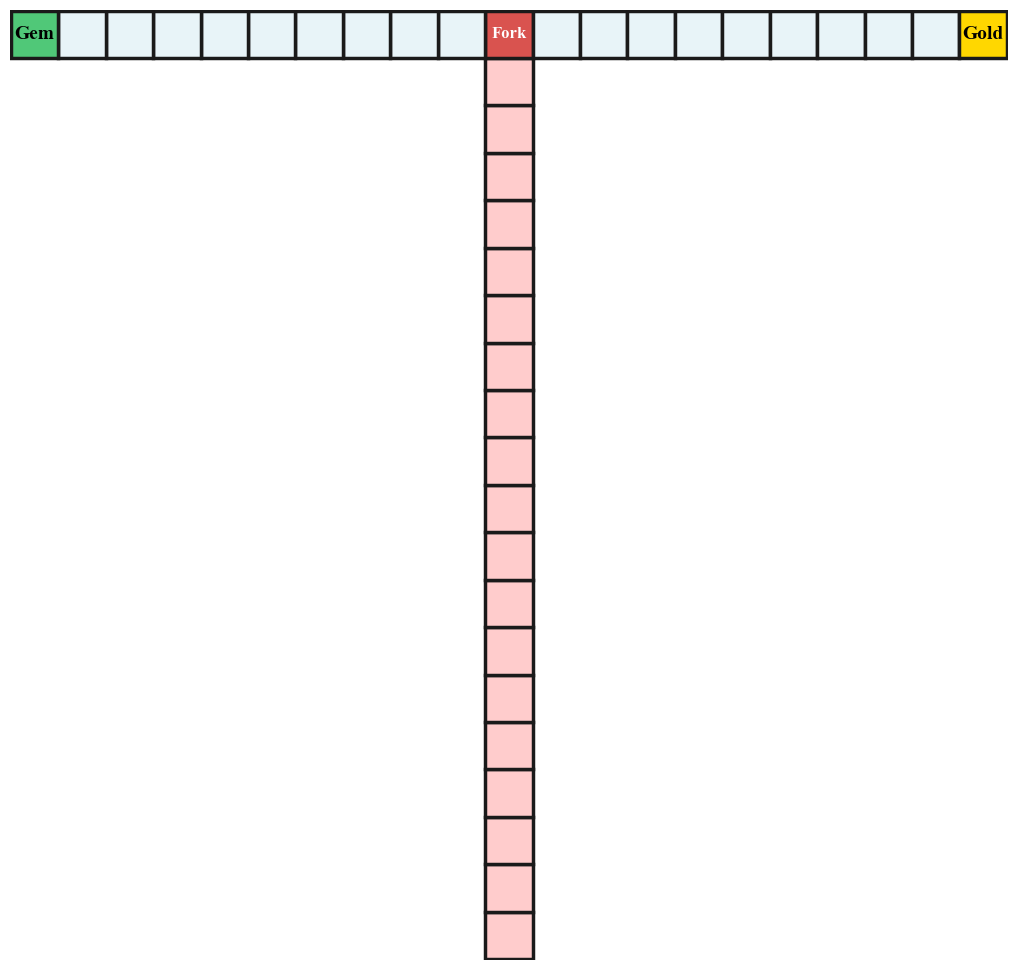


Running Exact Adaptive Optimistic Linear Support (OLS)...

Found 6 deterministic vertices.

Starting Exact LP Suboptimality Evaluation...
Traj:   0 | Mixed: 28.2% | Iso: 28.2% | Aug: 28.2%
Traj:   3 | Mixed: 7.4% | Iso: 11.0% | Aug: 6.4%
Traj:   6 | Mixed: 3.5% | Iso: 4.9% | Aug: 2.0%
Traj:  10 | Mixed: 2.5% | Iso: 2.6% | Aug: 0.6%
Traj:  13 | Mixed: 2.3% | Iso: 1.6% | Aug: 0.3%
Traj:  16 | Mixed: 2.2% | Iso: 1.0% | Aug: 0.1%
Traj:  20 | Mixed: 2.1% | Iso: 0.6% | Aug: 0.1%
Traj:  23 | Mixed: 1.9% | Iso: 0.3% | Aug: 0.1%
Traj:  26 | Mixed: 2.1% | Iso: 0.2% | Aug: 0.0%


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Traj:  30 | Mixed: 1.9% | Iso: 0.2% | Aug: 0.0%


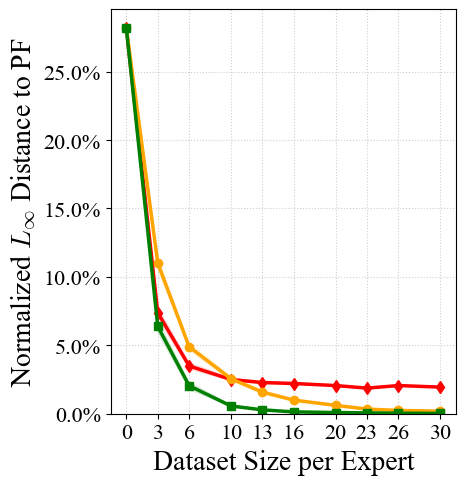

In [34]:
print("Initializing Slippery Y-Maze Environment...")
env = SlipperyYMazeMDP(branch_length=10, stem_length=20, gamma=0.9999)

visualize_y_maze_paper_transparent(env, filename="y_maze_env_empty.pdf")

pareto_points, pareto_policies = find_ccs_ols(env)
print(f"\nFound {len(pareto_points)} deterministic vertices.")

pol_A_true = pareto_policies[0]  # Gold Greedy
pol_B_true = pareto_policies[-1] # Gem Greedy

ideal = np.max(pareto_points, axis=0)
nadir = np.min(pareto_points, axis=0)
obj_ranges = np.clip(ideal - nadir, 1e-9, None)

trajectory_steps = np.linspace(0, 30, 10).astype(int)
num_trials = 100

results = {
    "mixed": {"mean": [], "std": []},
    "iso": {"mean": [], "std": []},
    "aug": {"mean": [], "std": []}
}

print("\nStarting Exact LP Suboptimality Evaluation...")
for n_traj in trajectory_steps:
    m_gaps, i_gaps, a_gaps = [], [], []
    
    for _ in range(num_trials):
        data_A = collect_trajectories(env, pol_A_true, n_traj)
        data_B = collect_trajectories(env, pol_B_true, n_traj)
        
        vA, vB = dict(data_A), dict(data_B)
        shared_B = [(s, a) for (s, a) in data_B if s not in vA or vA[s] == a]
        shared_A = [(s, a) for (s, a) in data_A if s not in vB or vB[s] == a]

        pi_mixed = build_stochastic_policy(env, data_A + data_B)
        pi_iso_A, pi_iso_B = build_stochastic_policy(env, data_A), build_stochastic_policy(env, data_B)
        pi_aug_A, pi_aug_B = build_stochastic_policy(env, data_A + shared_B), build_stochastic_policy(env, data_B + shared_A)

        m_gaps.append(calc_exact_linf_suboptimality(exact_policy_evaluation(env, pi_mixed), pareto_points, obj_ranges))
        i_gaps.append((calc_exact_linf_suboptimality(exact_policy_evaluation(env, pi_iso_A), pareto_points, obj_ranges) + 
                       calc_exact_linf_suboptimality(exact_policy_evaluation(env, pi_iso_B), pareto_points, obj_ranges)) / 2.0)
        a_gaps.append((calc_exact_linf_suboptimality(exact_policy_evaluation(env, pi_aug_A), pareto_points, obj_ranges) + 
                       calc_exact_linf_suboptimality(exact_policy_evaluation(env, pi_aug_B), pareto_points, obj_ranges)) / 2.0)
        
    results["mixed"]["mean"].append(np.mean(m_gaps)); results["mixed"]["std"].append(np.std(m_gaps))
    results["iso"]["mean"].append(np.mean(i_gaps)); results["iso"]["std"].append(np.std(i_gaps))
    results["aug"]["mean"].append(np.mean(a_gaps)); results["aug"]["std"].append(np.std(a_gaps))
    
    print(f"Traj: {n_traj:3d} | Mixed: {results['mixed']['mean'][-1]:.1%} | Iso: {results['iso']['mean'][-1]:.1%} | Aug: {results['aug']['mean'][-1]:.1%}")

plot_learning_curve(trajectory_steps, results, filename="y_maze_learning_curve.pdf")

 EVALUATING Y-MAZE ALPHA SWEEP AT FIXED N = 5 

--- Processing Alpha = 0.00 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 0.10 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 0.20 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 0.30 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 0.40 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 0.50 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 0.60 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 0.70 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 0.80 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 0.90 ---

Running Exact Adaptive Optimistic Linear Support (OLS)...
--- Processing Alpha = 1.00 ---

Running E

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


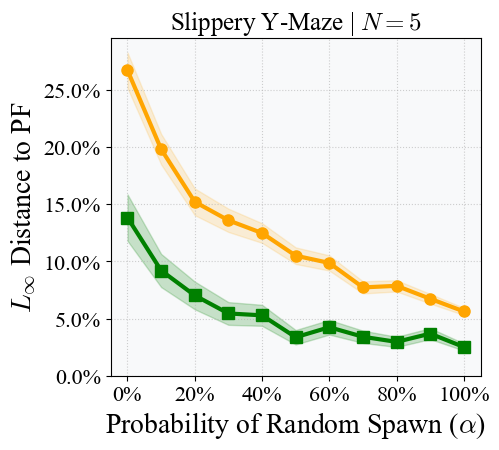

In [35]:

def plot_ymaze_alpha_sweep_fixed_N(alphas=np.linspace(0.0, 1.0, 11),
                                   fixed_n_traj=20, 
                                   num_trials=50):
    print("="*65)
    print(f" EVALUATING Y-MAZE ALPHA SWEEP AT FIXED N = {fixed_n_traj} ")
    print("="*65 + "\n")
    
    iso_means, iso_sems = [], []
    aug_means, aug_sems = [], []

    for alpha in alphas:
        print(f"--- Processing Alpha = {alpha:.2f} ---")
        
        env = SlipperyYMazeMDP(branch_length=10, stem_length=20, gamma=GAMMA, alpha=alpha)
        
        pareto_points, pareto_policies = find_ccs_ols(env)
        
        ideal_point = np.max(pareto_points, axis=0)
        nadir_point = np.min(pareto_points, axis=0)
        ranges = np.clip(ideal_point - nadir_point, 1e-9, None)
        
        pol_A_true = pareto_policies[0]   # Gold Greedy
        pol_B_true = pareto_policies[-1]  # Gem Greedy

        gaps_iso, gaps_aug = [], []
        
        for _ in range(num_trials):
            data_A = collect_trajectories(env, pol_A_true, fixed_n_traj)
            data_B = collect_trajectories(env, pol_B_true, fixed_n_traj)
            
            vA, vB = dict(data_A), dict(data_B)
            shared_B = [(s, a) for (s, a) in data_B if s not in vA or vA[s] == a]
            shared_A = [(s, a) for (s, a) in data_A if s not in vB or vB[s] == a]

            pi_iso_A = build_stochastic_policy(env, data_A)
            pi_iso_B = build_stochastic_policy(env, data_B)
            pi_aug_A = build_stochastic_policy(env, data_A + shared_B)
            pi_aug_B = build_stochastic_policy(env, data_B + shared_A)

            ret_iso_A = exact_policy_evaluation(env, pi_iso_A)
            ret_iso_B = exact_policy_evaluation(env, pi_iso_B)
            ret_aug_A = exact_policy_evaluation(env, pi_aug_A)
            ret_aug_B = exact_policy_evaluation(env, pi_aug_B)

            gap_iso_A = calc_exact_linf_suboptimality(ret_iso_A, pareto_points, ranges)
            gap_iso_B = calc_exact_linf_suboptimality(ret_iso_B, pareto_points, ranges)
            gaps_iso.append((gap_iso_A + gap_iso_B) / 2.0)
            
            gap_aug_A = calc_exact_linf_suboptimality(ret_aug_A, pareto_points, ranges)
            gap_aug_B = calc_exact_linf_suboptimality(ret_aug_B, pareto_points, ranges)
            gaps_aug.append((gap_aug_A + gap_aug_B) / 2.0)
            
        iso_means.append(np.mean(gaps_iso))
        iso_sems.append(np.std(gaps_iso) / np.sqrt(num_trials))
        aug_means.append(np.mean(gaps_aug))
        aug_sems.append(np.std(gaps_aug) / np.sqrt(num_trials))

    iso_means, iso_sems = np.array(iso_means), np.array(iso_sems)
    aug_means, aug_sems = np.array(aug_means), np.array(aug_sems)

    fig = plt.figure(figsize=(5, 5.2))
    ax = fig.gca()
    ax.set_facecolor('#f8f9fa')
    
    ax.plot(alphas, iso_means, 'o-', color='orange', linewidth=3, markersize=8, label='Isolated BC')
    ax.fill_between(alphas, np.maximum(0, iso_means - iso_sems), iso_means + iso_sems, color='orange', alpha=0.15)
    
    ax.plot(alphas, aug_means, 's-', color='green', linewidth=3, markersize=8, label='MA-BC (Ours)')
    ax.fill_between(alphas, np.maximum(0, aug_means - aug_sems), aug_means + aug_sems, color='green', alpha=0.2)

    ax.set_title(fr"Slippery Y-Maze | $N={fixed_n_traj}$")
    ax.set_xlabel(r"Probability of Random Spawn ($\alpha$)")
    ax.set_ylabel(r"$L_\infty$ Distance to PF")
    
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    
    ax.set_xticks(np.linspace(0.0, 1.0, 6))
    
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_ylim(bottom=0)
    
    fig.subplots_adjust(top=0.90, bottom=0.25, left=0.24, right=0.98)
    
    plt.savefig("ymaze_alpha_sweep.pdf", bbox_inches=None, dpi=300, transparent=True)
    plt.show()

alpha_values = np.linspace(0.0, 1.0, 11)
plot_ymaze_alpha_sweep_fixed_N(alphas=alpha_values, fixed_n_traj=5, num_trials=100)